In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np 
import seaborn as sns 
import folium
from folium.plugins import HeatMapWithTime
from datetime import datetime, timedelta

In [24]:
# import and read the merged csv file
merged_entire_data = pd.read_csv("/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/merged_crime_data.csv", parse_dates=["Standardized_Incident_Datetime"])

# filter according to "Focus Crimes"
# ------------------------------------

# list focus crimes
focus_crimes = ["assault","burglary","weapons","vandalism","traffic","fraud","drug", "sex offenses"]
# filter merged dataset
focus_data = merged_entire_data[merged_entire_data["Standardized_Category"].isin(focus_crimes)].copy()

# Removing "out of SF" district
# ------------------------------------
# since we are working on data for the inner city
focus_data = focus_data[focus_data["District"] != "out of sf"].copy()

# sanity checks
print (merged_entire_data["Standardized_Incident_Datetime"].dtype)
print("Focus dataset shape:", focus_data.shape)
focus_data.head()

datetime64[ns]
Focus dataset shape: (902416, 14)


,Incident_Number,Original_Category,Standardized_Category,Description,Day_of_Week,Standardized_Incident_Datetime,Date,Time,District,Resolution,Address,Longitude,Latitude,source
1,130119109,assault,assault,BATTERY,Sunday,2013-02-10 18:09:00,2013-02-10,18:09,mission,NONE,900 Block of DOLORES ST,-122.425237,37.754222,2003
2,61026720,assault,assault,BATTERY,Monday,2006-09-25 22:15:00,2006-09-25,22:15,northern,NONE,400 Block of FULTON ST,-122.425839,37.778486,2003
5,50822898,assault,assault,BATTERY,Saturday,2005-07-23 16:40:00,2005-07-23,16:40,ingleside,NONE,GENEVA AV / SANTOS ST,-122.420084,37.708311,2003
6,80749068,assault,assault,BATTERY,Friday,2008-05-23 12:10:00,2008-05-23,12:10,northern,NONE,300 Block of FELL ST,-122.423582,37.775904,2003
8,41091470,assault,assault,BATTERY,Thursday,2004-09-23 14:24:00,2004-09-23,14:24,richmond,NONE,2600 Block of BUSH ST,-122.440921,37.786126,2003


In [25]:
# check: print unique categories in focus dataset
print("Unique categories in focus dataset:\n", focus_data["Standardized_Category"].unique())

Unique categories in focus dataset:
 ['assault' 'fraud' 'vandalism' 'burglary' 'weapons' 'drug' 'traffic'
 'sex offenses']


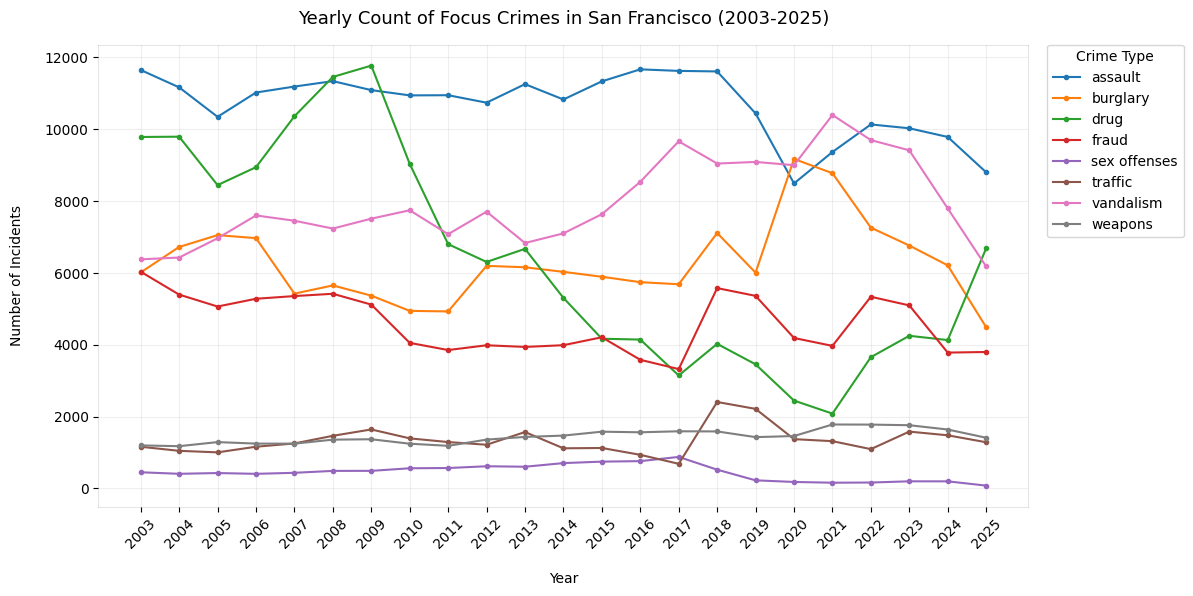

In [26]:
# Count total incidents per year for each focus crime
# ----------------------------------------------------

# Extract year from "Date"
focus_data["Date"] = pd.to_datetime(focus_data["Date"], errors="coerce")
focus_data["Year"] = focus_data["Date"].dt.year

# Remove 2026 (as it's incomplete for now)
focus_data = focus_data[focus_data["Year"] < 2026]

yearly_counts = focus_data.groupby(["Year", "Standardized_Category"]).size().unstack(fill_value=0)
# print(yearly_counts) # check

# plot yearly counts
# ----------------------------------------------------
# region Plot yearly crime
yearly_counts.plot(kind="line", marker=".", figsize=(12, 6))

plt.title("Yearly Count of Focus Crimes in San Francisco (2003-2025)", pad=15, fontsize=13)

# axis labels and ticks
plt.xlabel("Year", labelpad=15)
plt.ylabel("Number of Incidents", labelpad=15)
plt.xticks(yearly_counts.index, rotation=45)

plt.legend(
    title="Crime Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

# grid & opacity
plt.grid()
plt.grid(alpha=0.2)

# lighter frame
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_alpha(0.1)

plt.tight_layout
plt.show()
# endregion


In [27]:
burglary_data = focus_data[
    (focus_data['Standardized_Category'] == 'burglary') &
    (focus_data['Date'] >= '2019-07-01') &
    (focus_data['Date'] <= '2021-06-30')
]
df_crime = burglary_data.copy()

In [28]:
df_crime.head()


,Incident_Number,Original_Category,Standardized_Category,Description,Day_of_Week,Standardized_Incident_Datetime,Date,Time,District,Resolution,Address,Longitude,Latitude,source,Year
2049072,250650730,burglary,burglary,"Burglary, Non-residential, Att. Forcible",Thursday,2020-11-19 02:00:00,2020-11-19,02:00,central,Open or Active,JEFFERSON ST \ TAYLOR ST,-122.415802,37.808212,2018,2020
2095926,250159986,burglary,burglary,"Burglary, Apartment House, Forcible Entry",Saturday,2020-03-21 01:50:00,2020-03-21,01:50,taraval,Open or Active,ALEMANY BLVD \ KEMPTON AVE,-122.468430,37.711018,2018,2020
2103712,250222066,burglary,burglary,"Burglary, Other Bldg., Forcible Entry",Sunday,2020-03-01 00:00:00,2020-03-01,00:00,southern,Open or Active,02ND ST \ BRANNAN ST,-122.392075,37.781845,2018,2020
2152444,200104533,burglary,burglary,"Burglary, Store, Forcible Entry",Tuesday,2020-02-11 00:00:00,2020-02-11,00:00,taraval,Open or Active,INGLESIDE PATH \ OCEAN AVE,-122.463242,37.725590,2018,2020
2152453,200033374,burglary,burglary,"Burglary, Other Bldg., Unlawful Entry",Sunday,2019-11-10 10:00:00,2019-11-10,10:00,ingleside,Open or Active,27TH ST \ NOE ST,-122.431412,37.746632,2018,2019


In [29]:
df_crime["Standardized_Incident_Datetime"] = pd.to_datetime(
    df_crime["Standardized_Incident_Datetime"],
    errors="coerce"
)

df_crime["Latitude"] = pd.to_numeric(df_crime["Latitude"], errors="coerce")
df_crime["Longitude"] = pd.to_numeric(df_crime["Longitude"], errors="coerce")

df_crime = df_crime.dropna(subset=[
    "Standardized_Incident_Datetime",
    "Latitude",
    "Longitude"
]).copy()

df_crime["month"] = df_crime["Standardized_Incident_Datetime"].dt.to_period("M")

monthly_counts = (
    df_crime.groupby(["month", "Latitude", "Longitude"])
    .size()
    .reset_index(name="count")
)

months = sorted(monthly_counts["month"].unique())

data = []
time_index = []

for month in months:
    month_df = monthly_counts[monthly_counts["month"] == month].copy()

    if len(month_df) == 0:
        continue

    max_count = month_df["count"].max()
    global_max = monthly_counts["count"].max()
    month_df["weight"] = month_df["count"] / global_max

    month_points = month_df[["Latitude", "Longitude", "weight"]].values.tolist()
    data.append(month_points)

    start_date = month.start_time.strftime("%Y-%m-%d")
    end_date = month.end_time.strftime("%Y-%m-%d")
    time_index.append(f"{start_date} to {end_date}")

center = [df_crime["Latitude"].mean(), df_crime["Longitude"].mean()]

m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

hm = HeatMapWithTime(
    data,
    index=time_index,
    auto_play=False,
    max_opacity=0.3
)

hm.add_to(m)

m.save("visualizations/sf_crime_heatmap.html")

m